In [1]:
from prometheus_pandas import query
import datetime as dt
from zoneinfo import ZoneInfo
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

local_address = "gros-94.nancy.grid5000.fr"
local_port = "30090"
p = query.Prometheus(f"http://admin:prom-operator@{local_address}:{local_port}")    

local_tz = ZoneInfo("Europe/Paris")

def execute_query_range(experiment, metric_query, step, output_filename, plot=False):
    tput_series = []

    print("\nBeginning request execution")
    for label, config in experiment.items():    
        df_metric = p.query_range(
            query=metric_query,
            start=config['start'].isoformat(),
            end=config['end'].isoformat(),
            step=step
        )

        tput_series.append(df_metric)

    if tput_series:
        combined_df = pd.concat(tput_series, axis=1)
        combined_df.to_csv(output_filename, index_label='Time')
        print(f"\nFile saved : '{output_filename}'")
        if plot:
            plt.figure(figsize=(12, 8))
            ax = combined_df.boxplot(grid=True, patch_artist=True)
            plt.title(metric_query)
            plt.show()
    else:
        print("\nRequest Error")

### Experiment 1c

In [ ]:
exp_tw = { #TPUT 50k
    'rocks': {
        'start': dt.datetime(2025, 8, 13, 10, 13, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 13, 10, 23, 0, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 8, 13, 10, 30, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 13, 10, 40, 0, tzinfo=local_tz)
    },
    'forst(128-1)': {
        'start': dt.datetime(2025, 8, 13, 10, 48, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 13, 10, 58, 0, tzinfo=local_tz)
    },
    'forst(no cache)': {
        'start': dt.datetime(2025, 8, 13, 11, 13, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 13, 11, 23, 0, tzinfo=local_tz)
    }
}

exp_sw = {
    'rocks': {
        'start': dt.datetime(2025, 8, 13, 13, 46, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 13, 13, 56, 0, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 8, 13, 14, 5, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 13, 14, 15, 0, tzinfo=local_tz)
    },
    'forst(128-1)': {
        'start': dt.datetime(2025, 8, 13, 14, 28, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 13, 14, 38, 0, tzinfo=local_tz)
    },
    'forst(no cache)': {
        'start': dt.datetime(2025, 8, 13, 14, 51, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 13, 15, 1, 0, tzinfo=local_tz)
    }
}

### Queries

In [7]:
metric_query = 'flink_taskmanager_Status_JVM_CPU_Load{component="taskmanager"}'
step = "5s"
output_filename = 'exp1d_cpu_load.csv'
execute_query_range(exp_sw, metric_query, step, output_filename)

metric_query = 'flink_jobmanager_job_lastCheckpointDuration{component="jobmanager"}'
step = "60s"
output_filename = 'exp1d_cp_time.csv'
execute_query_range(exp_sw, metric_query, step, output_filename)

metric_query = 'sum(rate(container_network_receive_bytes_total{namespace="minio-tenant", pod=~"myminio-.*"}[2m]))'
step = "5s"
output_filename = 'exp1d_minio_bytes.csv'
execute_query_range(exp_sw, metric_query, step, output_filename)

metric_query = 'sum(flink_taskmanager_job_task_operator_column_family_rocksdb_total_sst_files_size{component="taskmanager"})'
step = "5s"
output_filename = 'exp1d_sst_size.csv'
execute_query_range(exp_sw, metric_query, step, output_filename)

metric_query = 'sum(rate(container_network_transmit_bytes_total{node="gros-97.nancy.grid5000.fr"}[2m]))'
step = "5s"
output_filename = 'exp1d_bytes_send.csv'
execute_query_range(exp_sw, metric_query, step, output_filename)

metric_query = 'flink_jobmanager_job_lastCheckpointSize{component="jobmanager"}'
step = "1m"
output_filename = 'exp1d_cp_size.csv'
execute_query_range(exp_sw, metric_query, step, output_filename)

metric_query = 'sum(rate(flink_taskmanager_job_task_operator_rocksdb_block_cache_hit{component="taskmanager"}[2m]))/(sum(rate(flink_taskmanager_job_task_operator_rocksdb_block_cache_miss{component="taskmanager"}[2m]))+sum(rate(flink_taskmanager_job_task_operator_rocksdb_block_cache_hit{component="taskmanager"}[2m])))'
step = "5s"
output_filename = 'exp1d_cache_hit_ratio.csv'
execute_query_range(exp_sw, metric_query, step, output_filename)

metric_query = 'rate(minio_bucket_traffic_received_bytes{job="minio"}[2m])'
step = "1m"
output_filename = 'exp1d_bucket_received_bytes_rate.csv'
execute_query_range(exp_sw, metric_query, step, output_filename)

metric_query = 'rate(minio_node_io_rchar_bytes{job=~"minio"}[2m])'
step = "1m"
output_filename = 'exp1d_read_bytes_rate.csv'
execute_query_range(exp_sw, metric_query, step, output_filename)

metric_query = 'rate(minio_node_io_wchar_bytes{job=~"minio"}[2m])'
step = "1m"
output_filename = 'exp1d_write_bytes_rate.csv'
execute_query_range(exp_sw, metric_query, step, output_filename)

metric_query = 'sum(minio_node_drive_used_bytes{job=~"minio"})'
step = "1m"
output_filename = 'exp1d_drive_used_bytes.csv'
execute_query_range(exp_sw, metric_query, step, output_filename)

metric_query = 'sum by (api) (minio_node_drive_latency_us{job=~"minio"})'
step = "1m"
output_filename = 'exp1d_operation_latency.csv'
execute_query_range(exp_sw, metric_query, step, output_filename)

metric_query = '(increase(minio_bucket_requests_total{job="minio"}[2m]))'
step = "1m"
output_filename = 'exp1d_operation_request_rate.csv' #type of operation (create/get/delete/... and its rate)
execute_query_range(exp_sw, metric_query, step, output_filename)


Beginning request execution

File saved : 'exp1d_cpu_load.csv'

Beginning request execution

File saved : 'exp1d_cp_time.csv'

Beginning request execution

File saved : 'exp1d_minio_bytes.csv'

Beginning request execution

File saved : 'exp1d_sst_size.csv'

Beginning request execution

File saved : 'exp1d_bytes_send.csv'

Beginning request execution

File saved : 'exp1d_cp_size.csv'

Beginning request execution

File saved : 'exp1d_cache_hit_ratio.csv'

Beginning request execution

File saved : 'exp1d_bucket_received_bytes_rate.csv'

Beginning request execution

File saved : 'exp1d_read_bytes_rate.csv'

Beginning request execution

File saved : 'exp1d_write_bytes_rate.csv'

Beginning request execution

File saved : 'exp1d_drive_used_bytes.csv'

Beginning request execution

File saved : 'exp1d_operation_latency.csv'

Beginning request execution

File saved : 'exp1d_operation_request_rate.csv'


### Boxplot from file

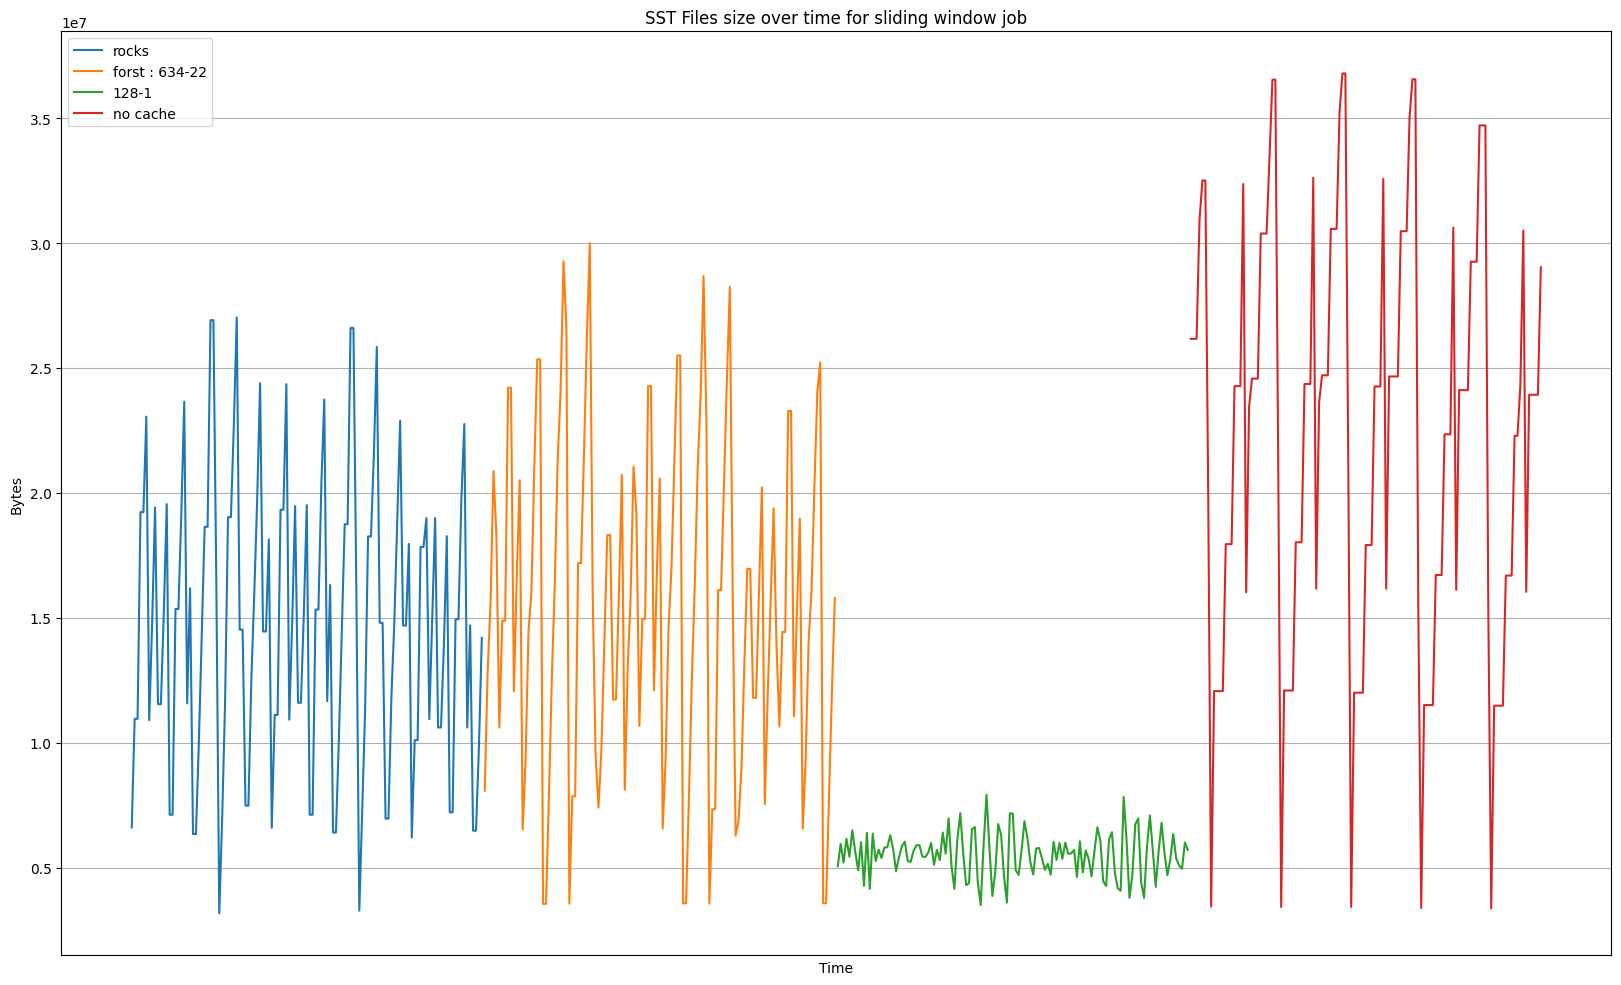

In [32]:
file_path = 'exp1d_sst_size.csv'

try:
    df = pd.read_csv(file_path, index_col=0)
    
    df.columns = ['rocks','forst : 634-22', '128-1', 'no cache']
    #df = df.iloc[:, :-1] 

    plt.figure(figsize=(20, 12))
    df.plot(grid=True, ax=plt.gca()) #style='o'

    #df.boxplot(grid=True, patch_artist=True)
    plt.title('SST Files size over time for sliding window job')
    plt.ylabel('Bytes')
    plt.xlabel('Time')
    plt.xticks([])
    #plt.yticks(np.arange(0.5, 1.2, 0.1))
    plt.savefig('exp1d_sst_size.png')
    
    plt.show()
    
except FileNotFoundError:
    print(f"Le fichier '{file_path}' est introuvable.")
except Exception as e:
    print(f"Une erreur est survenue : {e}")

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

files_50k = {'xp1results/50ktput/exp1a_50k_cp_time.csv': '50k TPUT'}
files_10k = {'xp1results/10ktput/exp1a_10k_cp_time.csv': '10k TPUT'}
files_maxtput = {'xp1results/maxtput/exp1a_maxtput_cp_time.csv': 'Max TPUT'}

def load_and_prepare_data(file_dict):
    """Charge un fichier CSV et prépare les données pour le boxplot."""
    file_path = list(file_dict.keys())[0]
    try:
        df = pd.read_csv(file_path, index_col=0)
        df.columns = [col.split('{')[0].split('_')[-1] if '{' in col else col for col in df.columns]
        df.columns = ['rocks', 'forst', 'forst_no_cache']
        return df
    except FileNotFoundError:
        print(f"Erreur : Le fichier {file_path} est introuvable.")
        return None

df_50k = load_and_prepare_data(files_50k)
df_10k = load_and_prepare_data(files_10k)
df_maxtput = load_and_prepare_data(files_maxtput)

if df_50k is not None and df_10k is not None and df_maxtput is not None:

    labels = ['rocks', 'forst', 'forst_no_cache']
    data_50k = [df_50k[col].dropna() for col in labels]
    data_10k = [df_10k[col].dropna() for col in labels]
    data_maxtput = [df_maxtput[col].dropna() for col in labels]

    plt.figure(figsize=(16, 9))
    fig, ax = plt.subplots(figsize=(16, 9))

    x_positions = np.arange(len(labels))
    width = 0.25

    bplot1 = ax.boxplot(data_maxtput, 
                        positions=x_positions - width, 
                        widths=width, 
                        patch_artist=True,
                        boxprops=dict(facecolor="cornflowerblue"))

    bplot2 = ax.boxplot(data_50k, 
                        positions=x_positions, 
                        widths=width, 
                        patch_artist=True,
                        boxprops=dict(facecolor="tomato"))

    bplot3 = ax.boxplot(data_10k, 
                        positions=x_positions + width, 
                        widths=width, 
                        patch_artist=True,
                        boxprops=dict(facecolor="lightgreen"))

    ax.set_ylabel('CP Time (ms)')
    ax.set_title('Comparison of Checkpointing time per configuration and throughput')
    
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels)
    ax.set_xlabel('Configuration')
    ax.yaxis.grid(True, linestyle='--')

    legend_50k = mpatches.Patch(color='cornflowerblue', label='Max TPUT')
    legend_10k = mpatches.Patch(color='tomato', label='50k TPUT')
    legend_maxtput = mpatches.Patch(color='lightgreen', label='10k TPUT')
    ax.legend(handles=[legend_50k, legend_10k, legend_maxtput])

    fig.tight_layout()
    plt.savefig('xp1results/boxplot_cp_time_comparison.png', dpi=300)
    plt.show()

Erreur : Le fichier xp1results/50ktput/exp1a_50k_cp_time.csv est introuvable.
Erreur : Le fichier xp1results/10ktput/exp1a_10k_cp_time.csv est introuvable.
Erreur : Le fichier xp1results/maxtput/exp1a_maxtput_cp_time.csv est introuvable.
